_Date: 25th April 2026  
Authors: Lydia, Soledad, Andre_

# Satellite Image Classification with EuroSAT

# Introduction

This notebook implements a full image classification pipeline on the **EuroSAT** dataset — a benchmark dataset of Sentinel-2 satellite imagery covering 10 land-use/land-cover classes (e.g. Forest, Highway, Industrial, Residential, etc.).

The notebook is structured as follows:
- **Section 0** — Exploratory Data Analysis (EDA)
- **Section 1** — Baseline CNN (trained from scratch)
- **Section 2** — Transfer Learning: Pretrained Model A and Pretrained Model B
- **Section 3** — Model Comparison & Final Selection
- **Section 4** — Interactive Web App for Model Inference

**Dataset sources:**
- [EuroSAT GitHub (Helber et al.)](https://github.com/phelber/EuroSAT)
- [`torchvision.datasets.EuroSAT`](https://pytorch.org/vision/stable/generated/torchvision.datasets.EuroSAT.html)

___________________________________________________

## Section 0: Exploratory Data Analysis (EDA)

In the present section, data has been downloaded and inspected. Additionnally, a series of actions have been implemented to support later sections' analysis, including:  
- EuroSAT dataset loading, inc. inspection of its structure
- Class Distribiton: Check of number of classes and class names, including assessment of classes' balance
- Visualisation of samples of images relative to each class
- Inspection of image dimensions, pixel value ranges, and per-channel statistics (mean & std) — these will inform the normalisation strategy throughout the project
- Outliers detection, missing values identification, underlying patterns and variables relationships modeling
- XXXX

### 0.1. Load dataset & inspect structure

#### Loading the Dataset

We loaded the full EuroSAT dataset (27,000 satellite images across 10 classes) with no transforms applied, then split it into three non-overlapping subsets: 70% for training, 15% for validation, and 15% for testing, using a randomly shuffled index list with a fixed seed (42) to ensure the split is reproducible every time we run the notebook.

In [ ]:
## Load dataset

# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import copy
from IPython.display import Image
from IPython.core.display import HTML



# Load the RGB version of EuroSAT
euro_raw = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=None,
)

# Quick identifying on a full raw dataset
eurosat_class_names = euro_raw.classes
num_eurosat_classes = len(eurosat_class_names)
dataset_size = len(euro_raw)

# Make our own train/validation/test split.
train_size = int(0.70 * dataset_size) #Data the model learns from
val_size = int(0.15 * dataset_size) #Data the model never trains on byt we check perfromance on it at the end of every epoch
test_size = dataset_size - train_size - val_size #Data the model never sees at all until we perform testing

# Fixed indices give us reproducible splits.
euro_generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size, generator=euro_generator).tolist()

#Slices the shuffled index into three non'overlapping chunks. NO image has been loaded into memory yet
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

#Creation of the three subsets (takes the object but only at the positions listed in the train_indices)
ds_train_euro_raw = Subset(euro_raw, train_indices)
ds_val_euro_raw = Subset(euro_raw, val_indices)
ds_test_euro_raw = Subset(euro_raw, test_indices)

print(f"EuroSAT examples: {dataset_size:,}")
print(f"Train / Val / Test: {train_size:,} / {val_size:,} / {test_size:,}")
print(f"Classes ({num_eurosat_classes}): {eurosat_class_names}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 289MB/s]


EuroSAT examples: 27,000
Train / Val / Test: 18,900 / 4,050 / 4,050
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


#### Inspecting the Structure

Before have inspect the dataset with the following actions:
1. **Shape and value range**
2. **Visual samples**

Batch image tensor: (32, 3, 64, 64) → (batch, channels, height, width)
Image dtype:        torch.uint8
Pixel range:        19 to 255
Label tensor:       (32,)
One label example:  1 → Forest


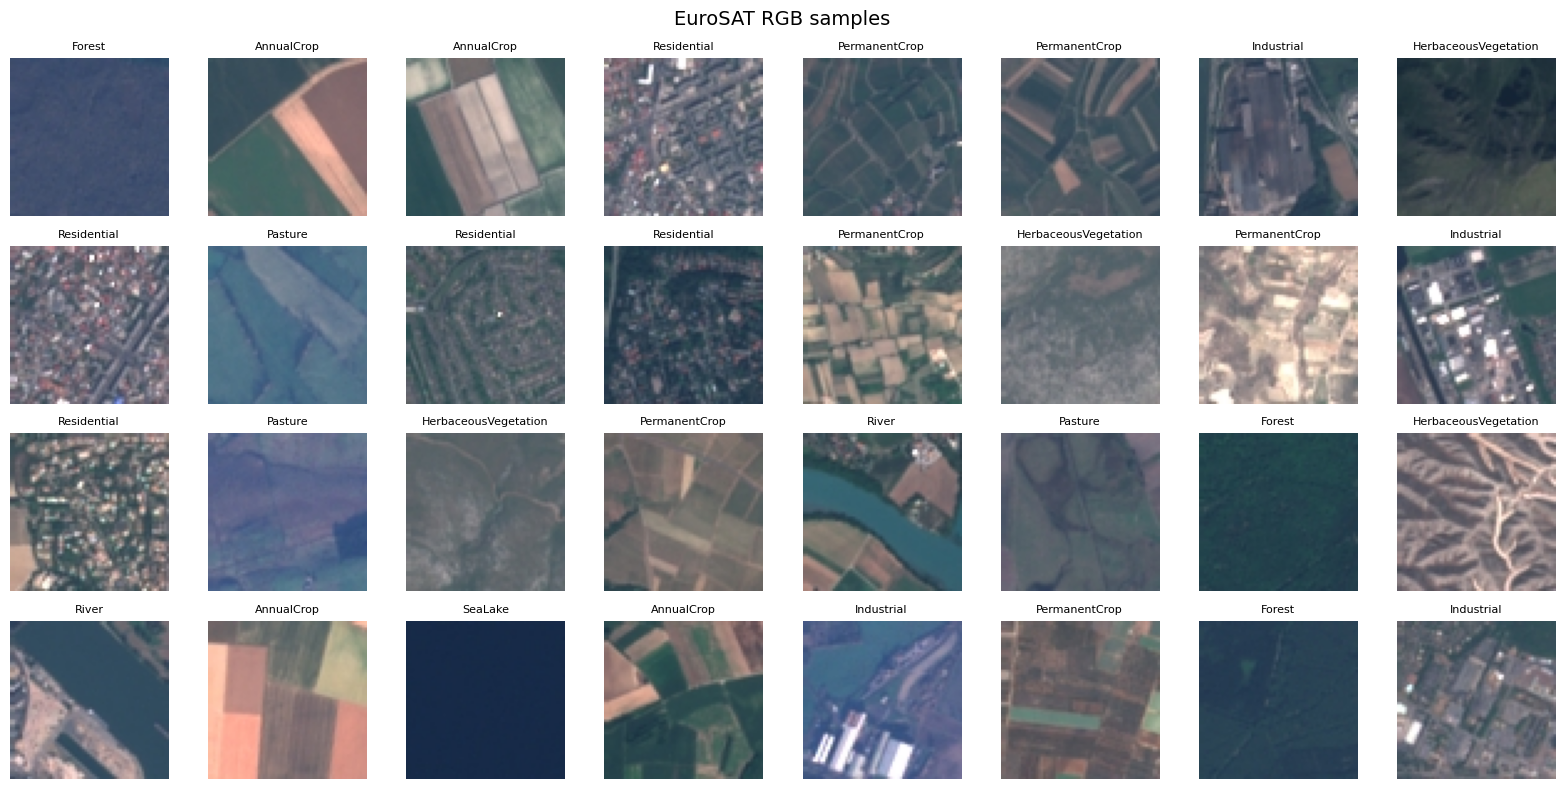

In [ ]:
## Inspect structure

# Inspect a small batch from the raw training split to inspect shape and value range.
to_uint8_tensor = transforms.PILToTensor()

example_items = [ds_train_euro_raw[i] for i in range(32)]
example_images_pil, example_labels_tuple = zip(*example_items)


#Grabbing 32 samples from the training set. Each image is a tuple of (PIL image, label integer)
#Neural networks can only work with numbers. So PyTorch automatically maps each class name to an integer when it loads the dataset, alphabetically:
example_images = torch.stack([to_uint8_tensor(img) for img in example_images_pil])
example_labels = torch.tensor(example_labels_tuple)


print(f"Batch image tensor: {tuple(example_images.shape)} → (batch, channels, height, width)")
print(f"Image dtype:        {example_images.dtype}")
print(f"Pixel range:        {example_images.min().item()} to {example_images.max().item()}")
print(f"Label tensor:       {tuple(example_labels.shape)}")
print(f"One label example:  {example_labels[0].item()} → {eurosat_class_names[example_labels[0].item()]}")

# Show a grid of random images - #Visualization of the images followign their ocnversion to tensors
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for ax, img, label in zip(axes.flat, example_images, example_labels):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(eurosat_class_names[label.item()], fontsize=8)
    ax.axis("off")

plt.suptitle("EuroSAT RGB samples", fontsize=14)
plt.tight_layout()
plt.show()

##### Notes:  
euro_raw — contains raw PIL images and integer labels, nothing has been converted  
example_images_pil / example_labels_tuple — still raw, just extracted and separated into two tuples  
example_images / example_labels — this is where the conversion to tensors finally happens

### 0.2. Class distribution

#### Data Exploration

Once the data has been staked, we wll proceed to conduct further analysis on the dataset to attain a global understanding of its content:
1. **Class balance** to assess potential misrepresentation or over-representaiton of some classes   
2. **Channel statistics** to understand how bright/colorful the images are
3. **Mean image per class** to uderstnad what large-scale visual patterns distinguish the classes  

,class,count,percentage
0,AnnualCrop,3000,11.111111
1,Forest,3000,11.111111
2,HerbaceousVegetation,3000,11.111111
7,Residential,3000,11.111111
9,SeaLake,3000,11.111111
3,Highway,2500,9.259259
6,PermanentCrop,2500,9.259259
4,Industrial,2500,9.259259
8,River,2500,9.259259
5,Pasture,2000,7.407407


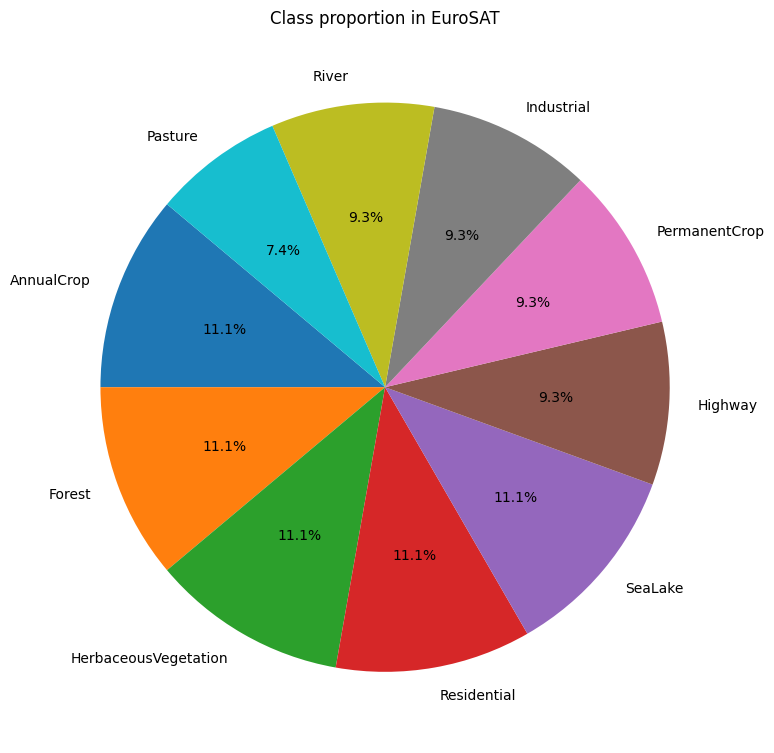

In [ ]:
# Class distribution to see if some classes are over-represented.
if hasattr(euro_raw, "targets"):
    all_euro_labels = np.array(euro_raw.targets) #takes the levels if they are called Targets
elif hasattr(euro_raw, "samples"):
    all_euro_labels = np.array([label for _, label in euro_raw.samples]) #if they are not called Taregts and they are called Samples
else:
    all_euro_labels = np.array([euro_raw[i][1] for i in range(len(euro_raw))])


label_counts = np.bincount(all_euro_labels, minlength=num_eurosat_classes)

class_distribution = pd.DataFrame({
    "class": eurosat_class_names,
    "count": label_counts,
    "percentage": 100 * label_counts / label_counts.sum(),
}).sort_values("count", ascending=False)

display(class_distribution)

# Pie chart for a quick overview of class proportions and to check for class imbalance
plt.figure(figsize=(8, 8))
plt.pie(
    class_distribution["count"],
    labels=class_distribution["class"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Class proportion in EuroSAT")
plt.tight_layout()
plt.show()

#### Conclusion:

The EuroSAT dataset is **well-balanced**: all 10 classes are similarly represented, each accounting for roughly 10% of the total 27,000 images. There are minor variations — a few classes sit closer to 7% while others reach 11% — but these differences are small enough that class imbalance is not a concern here.

Every class contains at least 2,000 images, which provides a solid and representative sample for training. This balance is a desirable property of EuroSAT and means we can trust overall accuracy as a meaningful metric, without needing to resort to weighted loss functions or oversampling strategies to compensate for skewed distributions.

,channel,mean_pixel_value,std_pixel_value
0,Red,86.040001,50.290001
1,Green,95.750000,34.040001
2,Blue,102.989998,28.790001


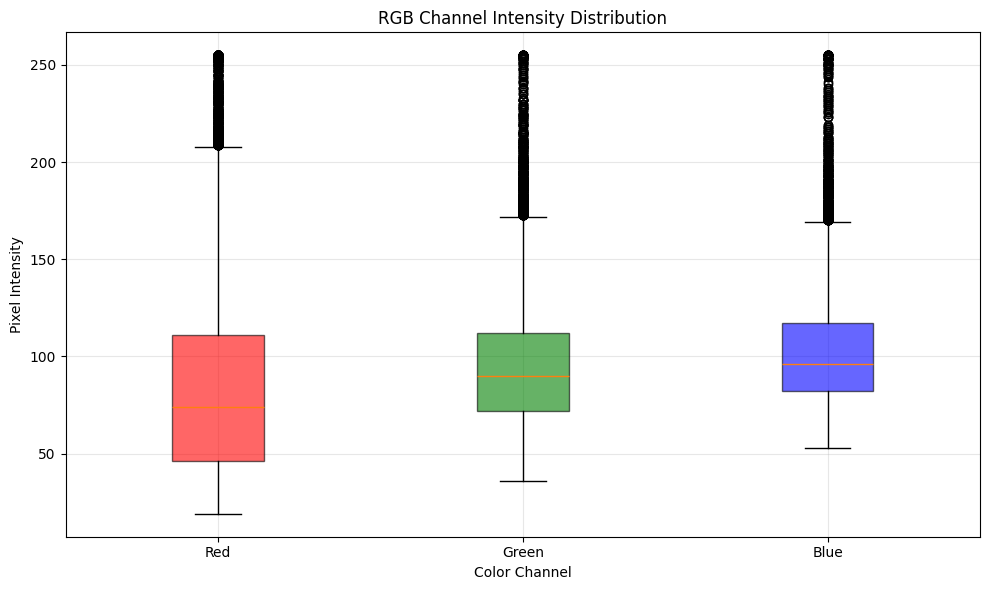

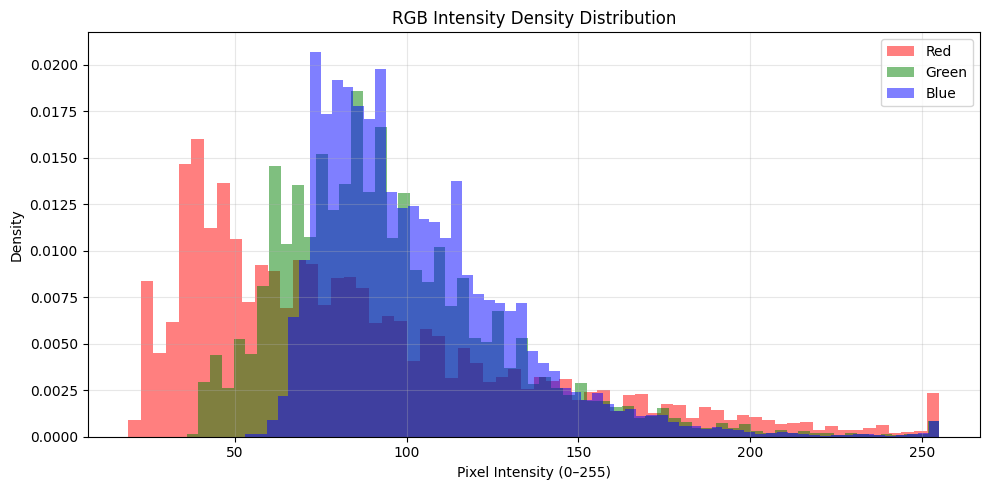

In [ ]:
# Channel statistics from a manageable sample to see how bright and colorful are the image.
# We keep values in the original 0-255 range for this EDA step.
eda_indices = indices[:2048]

eda_images = torch.stack([
    to_uint8_tensor(euro_raw[i][0])
    for i in eda_indices
])

eda_images_np = eda_images.permute(0, 2, 3, 1).numpy().astype("float32")

channel_names = ["Red", "Green", "Blue"]
channel_means = eda_images_np.mean(axis=(0, 1, 2))
channel_stds = eda_images_np.std(axis=(0, 1, 2))

channel_stats = pd.DataFrame({
    "channel": channel_names,
    "mean_pixel_value": channel_means,
    "std_pixel_value": channel_stds,
}).round(2)

display(channel_stats)


# Channel boxplot to compare intensity distribution across RGB channels

# Flatten and under sampling for the boxplot
sample_pixels = eda_images_np.reshape(-1, 3)[::500]


plt.figure(figsize=(10, 6))

box = plt.boxplot(
    [sample_pixels[:, 0], sample_pixels[:, 1], sample_pixels[:, 2]],
    tick_labels=["Red", "Green", "Blue"],
    patch_artist=True
)

for patch, color in zip(box["boxes"], ["red", "green", "blue"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title("RGB Channel Intensity Distribution")
plt.xlabel("Color Channel")
plt.ylabel("Pixel Intensity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# # Histogram to check whether pixel values are concentrated in high or low intensity ranges
plt.figure(figsize=(10, 5))

for i, (color, name) in enumerate(zip(["red", "green", "blue"], ["Red", "Green", "Blue"])):
    plt.hist(
        sample_pixels[:, i],
        bins=64, color=color, alpha=0.5,
        label=name, density=True
    )

plt.title("RGB Intensity Density Distribution")
plt.xlabel("Pixel Intensity (0–255)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 0.3. Sample images per class

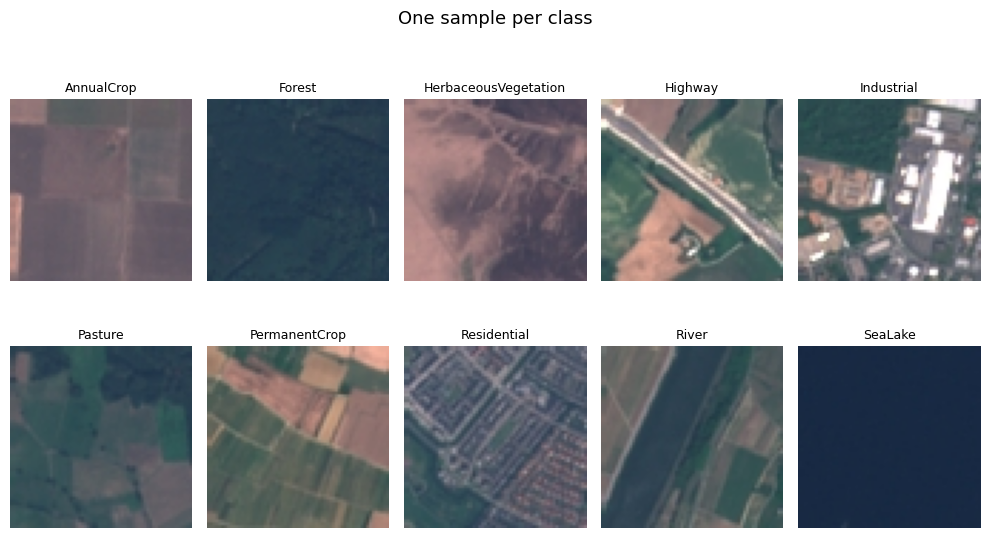

In [ ]:
# Sample image per class
classes = euro_raw.classes
fig, axes = plt.subplots(2, 5, figsize=(10, 6))

for ax, cls in zip(axes.flatten(), classes):
    idx = next(i for i, (_, label) in enumerate(euro_raw) if euro_raw.classes[label] == cls)
    img = to_uint8_tensor(euro_raw[idx][0]).permute(1, 2, 0).numpy()
    ax.imshow(img.astype("uint8"))
    ax.set_title(cls, fontsize=9)
    ax.axis("off")

plt.suptitle("One sample per class", fontsize=13)
plt.tight_layout()
plt.show()

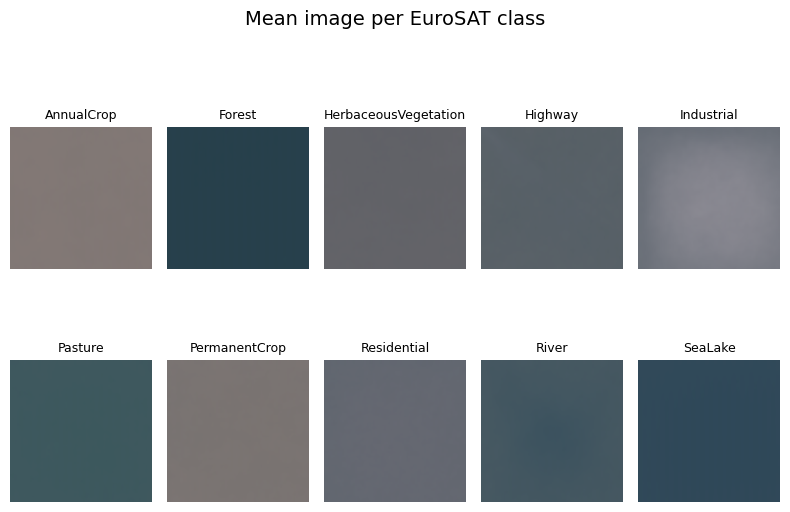

In [ ]:
# Mean image per class to uderstnad what large-scale visual patterns distinguish the classe

# This compresses each class into its average visual pattern.
euro_tensor_dataset = datasets.EuroSAT(
    root="./data",
    download=False,
    transform=transforms.PILToTensor(),
)

euro_tensor_loader = DataLoader(
    euro_tensor_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0,
)

class_sums = np.zeros((num_eurosat_classes, 3, 64, 64), dtype="float64")
class_counts = np.zeros(num_eurosat_classes, dtype="int64")

for images, labels in euro_tensor_loader:
    images_np = images.numpy().astype("float64")
    labels_np = labels.numpy()

    for class_idx in range(num_eurosat_classes):
        mask = labels_np == class_idx
        if mask.any():
            class_sums[class_idx] += images_np[mask].sum(axis=0)
            class_counts[class_idx] += mask.sum()

class_mean_images = class_sums / class_counts[:, None, None, None]

fig, axes = plt.subplots(2, 5, figsize=(8, 6))
for ax, class_idx in zip(axes.flat, range(num_eurosat_classes)):
    mean_image = class_mean_images[class_idx].transpose(1, 2, 0) / 255.0
    ax.imshow(np.clip(mean_image, 0, 1))
    ax.set_title(eurosat_class_names[class_idx], fontsize=9)
    ax.axis("off")

plt.suptitle("Mean image per EuroSAT class", fontsize=14)
plt.tight_layout()
plt.show()

____________________________________________

## Section 1: Baseline CNN (Trained from Scratch)

In this section we design and train a CNN from scratch to establish a baseline performance on EuroSAT. The goal is not perfection — it is to understand what a simple model can achieve and to use it as a reference point for the pretrained models in later sections.

We perform a systematic hyperparameter search over:

| Hyperparameter | Values explored |
|---|---|
| Learning rate | e.g. 1e-2, 1e-3, 1e-4 |
| Batch size | e.g. 32, 64, 128 |
| Optimiser | e.g. SGD, Adam |
| Data augmentation | type & intensity |
| Number of conv layers | e.g. 3, 4, 5 |
| Dropout | with / without, rate |
| Batch normalisation | with / without |

Note: All results have been saved to at a latter stage be plotted and compared.


### 1.1. Data Loading and augmentation

In [ ]:
# Define the number of samples to be processed in a single pass through the network
BATCH_SIZE_EURO = 64

def get_best_device():
    """Use the fastest available device, while keeping CPU as the safe default."""
    if torch.cuda.is_available():
        return torch.device("cuda") # if you have an NVIDIA GPU
    if torch.backends.mps.is_available():
        return torch.device("mps")      # if you have an apple silicon chip (M1/M2...etc)
    return torch.device("cpu")

device = get_best_device()

# Define image transformations for training to increase model robustness (Data Augmentation)
euro_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip images horizontally with a 50% probability
    transforms.RandomVerticalFlip(p=0.5),     # Randomly flip images vertically with a 50% probability
    transforms.RandomRotation(degrees=18), # Randomly rotate images within a range of +/- 18 degrees
    transforms.ToTensor(),     # Convert PIL images or numpy arrays to PyTorch floating point tensors
])

# Define image transformations for validation and testing
euro_eval_transform = transforms.ToTensor() # Convert PIL images or numpy arrays to PyTorch floating point tensors

# Define image transformations for validation and testing
euro_test_transform = transforms.ToTensor() # Convert PIL images or numpy arrays to PyTorch floating point tensors


# Initialize the EuroSAT dataset object specifically for training, applying the augmentation pipeline
euro_train_full = datasets.EuroSAT(
    root="./data",
    download=False,
    transform=euro_train_transform,
)

# Initialize the EuroSAT dataset object for evaluation, applying only the ToTensor transformation
euro_eval_full = datasets.EuroSAT(
    root="./data",
    download=False,
    transform=euro_eval_transform,
)

# Initialize the EuroSAT dataset object for testing, applying only the ToTensor transformation
euro_test_full = datasets.EuroSAT(
    root="./data",
    download=False,
    transform=euro_test_transform,
)

# Create a training Subset, validation Subset and test Subset.
train_euro = Subset(euro_train_full, train_indices) #Transformed to tensor, and some images are flipped, rotated, etc
val_euro = Subset(euro_eval_full, val_indices) #Transformed to Tensor
test_euro = Subset(euro_test_full, test_indices) #Transformed to Tensor

# Create a DataLoader for the training set to handle batching and shuffling
train_euro_loader = DataLoader(
    train_euro,
    batch_size=BATCH_SIZE_EURO,
    shuffle=True, #We shuffle the data within the badges
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

# Create a DataLoader for the validation set
val_euro_loader = DataLoader(
    val_euro,
    batch_size=BATCH_SIZE_EURO,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

# Create a DataLoader for the test set
test_euro_loader = DataLoader(
    test_euro,
    batch_size=BATCH_SIZE_EURO,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)


### 1.2. Model architecture

In [ ]:
# Create the model
class EuroSATCNN(nn.Module):
    """Small CNN for 64×64 RGB satellite images.

    BatchNorm stabilizes training by normalizing intermediate activations, and
    global average pooling keeps the classifier small by averaging each feature
    map into one number.
    """

    def __init__(self, num_classes):
        super().__init__()

        # Block 1: learn low-level features such as edges and simple textures.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: combine earlier features into more abstract patterns.
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: combine earlier features into more abstract patterns.
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Filter
        self.pool = nn.MaxPool2d(kernel_size=2)

        # Dense Neural Network
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Global average pooling: (batch, 128, 8, 8) → (batch, 128, 1, 1)
        x = F.adaptive_avg_pool2d(x, output_size=1)
        # Flatten all dimensions except the batch dimension.
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)

        return self.classifier(x)


model_eurosat = EuroSATCNN(num_classes=num_eurosat_classes).to(device)

In [ ]:
# Summary of the model: cration of the parameters table
def summarize_model(model, input_shape, device):
    """Print a compact layer-by-layer shape and parameter summary.

    We use forward hooks so students can see what happens to a tensor as it flows
    through the model.
    """
    rows = []
    hooks = []

    def count_parameters(model):
        """
        Count only trainable parameters.

        Trainable parameters are those with requires_grad=True,
        meaning they will be updated during backpropagation/optimization.
        """
        return sum(
            p.numel()  # numel() returns the total number of elements in the tensor
            for p in model.parameters()  # iterate over all parameter tensors in the model
            if p.requires_grad  # filter: only include parameters that are trainable
        )

    def register_hook(name, module):
        def hook(module, inputs, output):
            params = sum(p.numel() for p in module.parameters(recurse=False))
            output_shape = tuple(output.shape) if torch.is_tensor(output) else str(type(output))
            rows.append((name, module.__class__.__name__, output_shape, params))

        hooks.append(module.register_forward_hook(hook))

    for name, module in model.named_modules():
        if name and not list(module.children()):
            register_hook(name, module)

    #model.eval()
    dummy_input = torch.zeros(1, *input_shape, device=device)
    with torch.inference_mode():
        model(dummy_input)

    for hook in hooks:
        hook.remove()

    print(f"{'Layer':<22} {'Type':<18} {'Output shape':<22} {'Parameters':>12}")
    print("-" * 80)
    for name, layer_type, output_shape, params in rows:
        print(f"{name:<22} {layer_type:<18} {str(output_shape):<22} {params:>12,}")
    print("-" * 80)
    print(f"{'TOTAL TRAINABLE PARAMETERS':<64} {count_parameters(model):>12,}")

summarize_model(model_eurosat, input_shape=(3, 64, 64), device=device)

Layer                  Type               Output shape             Parameters
--------------------------------------------------------------------------------
conv1                  Conv2d             (1, 32, 64, 64)                 896
bn1                    BatchNorm2d        (1, 32, 64, 64)                  64
pool                   MaxPool2d          (1, 32, 32, 32)                   0
conv2                  Conv2d             (1, 64, 32, 32)              18,496
bn2                    BatchNorm2d        (1, 64, 32, 32)                 128
pool                   MaxPool2d          (1, 64, 16, 16)                   0
conv3                  Conv2d             (1, 128, 16, 16)             73,856
bn3                    BatchNorm2d        (1, 128, 16, 16)                256
pool                   MaxPool2d          (1, 128, 8, 8)                    0
dropout                Dropout            (1, 128)                          0
classifier             Linear             (1, 10)            

In [ ]:
# Model Architecture map
#Image(filename="/content/CNNModelArchitecture.png", width=700, height=400)

### 1.3. Model Trainning

In [ ]:
# Function Train
def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience,
    min_delta=0.0,
    verbose=True,
):
    """Train a model and restore the weights with the best validation loss."""
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0



    def train_one_epoch(model, dataloader, criterion, optimizer, device):
        """Run one training pass over the data.

        The model is put in train mode so layers such as Dropout and BatchNorm behave
        correctly during learning.
        """
        model.train()
        running_loss = 0.0
        running_correct = 0
        n_examples = 0

        for images, labels in dataloader:    # remember that the dataloader will spit out one batch of images, and one batch of labels at each iteration
            optimizer.zero_grad(set_to_none=True)
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)  # forward pass
            loss = criterion(logits, labels)    # calculate the loss
            loss.backward()                     # backprop
            optimizer.step()                    # update the weights

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            n_examples += batch_size

        return {
            "loss": running_loss / n_examples,
            "accuracy": running_correct / n_examples,
        }


    def evaluate_model(model, dataloader, criterion, device):
        """Evaluate without tracking gradients.

        `torch.inference_mode()` saves memory and makes evaluation faster because we
        are not updating the model.
        """
        model.eval()
        running_loss = 0.0
        running_correct = 0
        n_examples = 0

        with torch.inference_mode():
            for images, labels in dataloader:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                running_loss += loss.item() * batch_size
                running_correct += (logits.argmax(dim=1) == labels).sum().item()
                n_examples += batch_size

        return running_loss / n_examples, running_correct / n_examples



    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)

        history["loss"].append(train_stats["loss"])
        history["accuracy"].append(train_stats["accuracy"])
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss: {train_stats['loss']:.4f}, "
                f"train acc: {train_stats['accuracy']:.4f} | "
                f"val loss: {val_loss:.4f}, "
                f"val acc: {val_accuracy:.4f}"
            )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping: validation loss did not improve for {patience} epochs.")
            break

    model.load_state_dict(best_state)
    return history

In [ ]:
# Training settings - 1
criterion_euro = nn.CrossEntropyLoss()
optimizer_euro = torch.optim.Adam(model_eurosat.parameters(), lr=0.001)
epochs = 12
patience = 3

model_eurosat_1 = fit_model(
    model=model_eurosat,
    train_loader=train_euro_loader,
    val_loader=val_euro_loader,
    criterion=criterion_euro,
    optimizer=optimizer_euro,
    device=device,
    epochs=epochs,
    patience=patience,
)

Epoch 01/12 | train loss: 1.0115, train acc: 0.6536 | val loss: 0.9583, val acc: 0.6504
Epoch 02/12 | train loss: 0.7386, train acc: 0.7414 | val loss: 0.8757, val acc: 0.6916
Epoch 03/12 | train loss: 0.6633, train acc: 0.7677 | val loss: 0.9757, val acc: 0.6694
Epoch 04/12 | train loss: 0.6085, train acc: 0.7865 | val loss: 0.5896, val acc: 0.7926
Epoch 05/12 | train loss: 0.5712, train acc: 0.7993 | val loss: 1.1514, val acc: 0.6314
Epoch 06/12 | train loss: 0.5504, train acc: 0.8085 | val loss: 1.2565, val acc: 0.5978
Epoch 07/12 | train loss: 0.5146, train acc: 0.8226 | val loss: 0.8129, val acc: 0.7546
Early stopping: validation loss did not improve for 3 epochs.


In [ ]:
# Training settings - 2
criterion_euro = nn.CrossEntropyLoss()
optimizer_euro = torch.optim.Adam(model_eurosat.parameters(), lr=0.1)
epochs = 30
patience = 5

model_eurosat_2 = fit_model(
    model=model_eurosat,
    train_loader=train_euro_loader,
    val_loader=val_euro_loader,
    criterion=criterion_euro,
    optimizer=optimizer_euro,
    device=device,
    epochs=epochs,
    patience=patience,
)

Epoch 01/30 | train loss: 1.4278, train acc: 0.5104 | val loss: 10.2764, val acc: 0.1914
Epoch 02/30 | train loss: 1.0476, train acc: 0.6271 | val loss: 0.8400, val acc: 0.6844
Epoch 03/30 | train loss: 0.9542, train acc: 0.6571 | val loss: 1.9422, val acc: 0.4822
Epoch 04/30 | train loss: 0.9384, train acc: 0.6713 | val loss: 0.7928, val acc: 0.7091
Epoch 05/30 | train loss: 0.9046, train acc: 0.6788 | val loss: 0.7067, val acc: 0.7420
Epoch 06/30 | train loss: 0.8522, train acc: 0.7014 | val loss: 1.2656, val acc: 0.5780
Epoch 07/30 | train loss: 0.8334, train acc: 0.7074 | val loss: 0.9016, val acc: 0.6514
Epoch 08/30 | train loss: 0.8086, train acc: 0.7198 | val loss: 0.8329, val acc: 0.7188
Epoch 09/30 | train loss: 0.8081, train acc: 0.7197 | val loss: 0.8195, val acc: 0.7235
Epoch 10/30 | train loss: 0.7562, train acc: 0.7321 | val loss: 1.9870, val acc: 0.5506
Early stopping: validation loss did not improve for 5 epochs.


In [ ]:
# Training settings - 3
criterion_euro = nn.CrossEntropyLoss()
optimizer_euro = torch.optim.RMSprop(model_eurosat.parameters(), lr=0.005)
epochs = 25
patience = 5

model_eurosat_3 = fit_model(
    model=model_eurosat,
    train_loader=train_euro_loader,
    val_loader=val_euro_loader,
    criterion=criterion_euro,
    optimizer=optimizer_euro,
    device=device,
    epochs=epochs,
    patience=patience,
)

Epoch 01/25 | train loss: 0.7252, train acc: 0.7452 | val loss: 0.5738, val acc: 0.7941
Epoch 02/25 | train loss: 0.6936, train acc: 0.7535 | val loss: 0.5301, val acc: 0.8138
Epoch 03/25 | train loss: 0.6827, train acc: 0.7593 | val loss: 0.5344, val acc: 0.8128
Epoch 04/25 | train loss: 0.6623, train acc: 0.7640 | val loss: 0.5187, val acc: 0.8180
Epoch 05/25 | train loss: 0.6591, train acc: 0.7671 | val loss: 0.5263, val acc: 0.8160
Epoch 06/25 | train loss: 0.6477, train acc: 0.7729 | val loss: 0.7042, val acc: 0.7459
Epoch 07/25 | train loss: 0.6455, train acc: 0.7721 | val loss: 0.5056, val acc: 0.8200
Epoch 08/25 | train loss: 0.6385, train acc: 0.7737 | val loss: 0.5617, val acc: 0.8059
Epoch 09/25 | train loss: 0.6385, train acc: 0.7765 | val loss: 0.5292, val acc: 0.8121
Epoch 10/25 | train loss: 0.6347, train acc: 0.7767 | val loss: 0.5020, val acc: 0.8247
Epoch 11/25 | train loss: 0.6193, train acc: 0.7781 | val loss: 0.5355, val acc: 0.8123
Epoch 12/25 | train loss: 0.6054

### 1.4. Model Evaluation

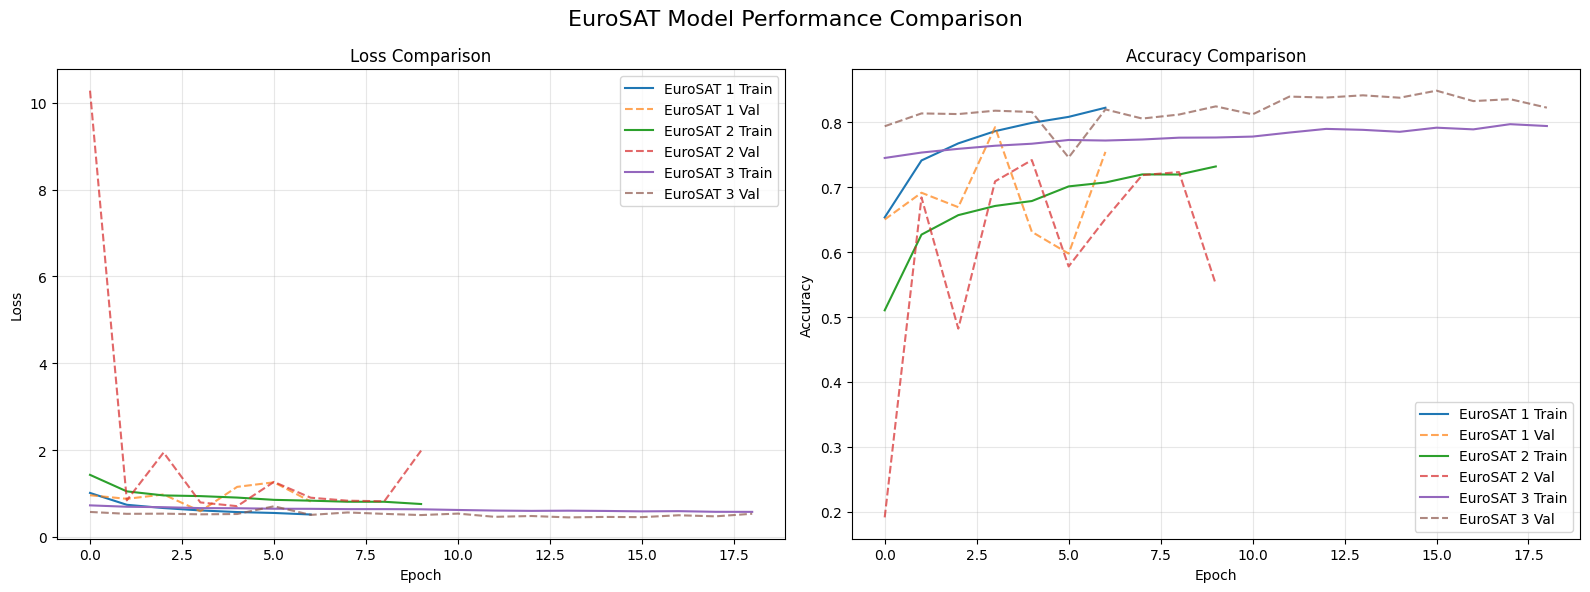

In [ ]:
# Plot epoch history

# Organize your histories into a dictionary for easy iteration
histories = {
    "EuroSAT 1": model_eurosat_1,
    "EuroSAT 2": model_eurosat_2,
    "EuroSAT 3": model_eurosat_3
}

# --- Plot training curves side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define metrics and their corresponding titles/labels
metrics = [("loss", "Loss Comparison"), ("accuracy", "Accuracy Comparison")]

for i, (metric, title) in enumerate(metrics):
    for name, history in histories.items():
        # Plot training data
        axes[i].plot(history[metric], label=f"{name} Train")
        # Plot validation data with a dashed line
        axes[i].plot(history[f"val_{metric}"], "--", label=f"{name} Val", alpha=0.7)

    axes[i].set_title(title)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(metric.capitalize())
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("EuroSAT Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
#To be completed

### 1.5. Save Model

In [ ]:
#To be completed

In [ ]:
#To be completed in json or text file

____________________

## Section 2: Transfer Learning with Pretrained Models

### 2.1. Pretrained Model A




( This is a proposition. Lydia) We choose ResNet-50 as a transfer learning baseline because it is a well-established deep convolutional neural network that has demonstrated strong performance on image classification tasks. Pretrained on ImageNet, it provides robust general visual feature extraction (edges, textures, shapes), which can be effectively transferred to satellite image classification tasks such as EuroSAT. This allows a fair comparison with a CNN trained from scratch

In [ ]:
# Step 1: Import required libraries for loading pretrained CNN from Hugging Face
import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModelForImageClassification


# ============================================================
# Step 2: Load a CNN pretrained model from Hugging Face Hub
# ============================================================

# This model is already trained on large image datasets
model_name = "microsoft/resnet-50"

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=10,  # EuroSAT has 10 classes
    ignore_mismatched_sizes=True  # IMPORTANT FIX
    )


# ============================================================
#STEP 3 — Load the image processor
# ============================================================
# The image processor contains the exact preprocessing pipeline
# used during ResNet-50 pretraining on ImageNet.
#
# It stores:
# - the expected image size
# - normalization mean and standard deviation
# - channel ordering
#
# Using it ensures that our EuroSAT images are formatted exactly as the pretrained model expects.
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")

print(processor)


resnet_transform = transforms.Compose([
  transforms.Resize((224, 224)), # ResNet expects 224x224
  transforms.ToTensor(),
  transforms.Normalize(
      mean=processor.image_mean, # ImageNet mean from processor
      std=processor.image_std # ImageNet std from processor
) ])


euro_resnet_full = datasets.EuroSAT(root="./data", download=False, transform=resnet_transform)
euro_resnet_class_names = euro_resnet_full.classes

train_resnet_loader = DataLoader(Subset(euro_resnet_full, train_indices), batch_size=32, shuffle=True, num_workers=0)
val_resnet_loader = DataLoader(Subset(euro_resnet_full, val_indices), batch_size=32, shuffle=False, num_workers=0)
test_resnet_loader = DataLoader(Subset(euro_resnet_full, test_indices), batch_size=32, shuffle=False, num_workers=0)


# ============================================================
# STEP 4 — Move model to the appropriate device
# ============================================================
# Deep learning is much faster on GPU.
# If CUDA is available, PyTorch will use it automatically.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(f"Using device: {device}")



# ============================================================
# STEP 5 — Freeze the pretrained convolutional backbone
# ============================================================
# We keep the feature extractor unchanged and train only
# the final classification layer.
#
# This is the standard transfer learning approach:
# - faster training
# - fewer parameters to optimize
# - reduced overfitting

for param in model.base_model.parameters():
    param.requires_grad = False

print("Backbone frozen successfully.")


# ============================================================
# STEP 6 — Define loss function and optimizer
# ============================================================
# CrossEntropyLoss is the standard choice for multiclass
# image classification.
#
# The optimizer updates only trainable parameters
# (the new classification head).

import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print("Loss function and optimizer initialized.")



# ============================================================
# STEP 7 — Verify trainable parameters
# ============================================================
# This sanity check confirms that only the classifier
# will be updated during training.

trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")



# ============================================================
# STEP 9 — Training loop
# ============================================================

num_epochs = 5

for epoch in range(num_epochs):
  model.train()

  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in train_resnet_loader:
    images = images.to(device)
    labels = labels.to(device)

  optimizer.zero_grad()

  outputs = model(images).logits
  loss = criterion(outputs, labels)

  loss.backward()
  optimizer.step()

  running_loss += loss.item()

  _, predicted = torch.max(outputs, 1)
  total += labels.size(0)
  correct += (predicted == labels).sum().item()

  train_accuracy = 100 * correct / total
  avg_loss = running_loss / len(train_resnet_loader)

  print(
  f"Epoch [{epoch+1}/{num_epochs}], "
  f"Loss: {avg_loss:.4f}, "
  f"Train Accuracy: {train_accuracy:.2f}%"
  )


# ============================================================
# STEP 10 — Evaluate model on test set
# ============================================================

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in test_resnet_loader:
    images = images.to(device)
    labels = labels.to(device)

outputs = model(images).logits
_, predicted = torch.max(outputs, 1)

total += labels.size(0)
correct += (predicted == labels).sum().item()

all_preds.extend(predicted.cpu().numpy())
all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy of pretrained ResNet-50: {test_accuracy:.2f}%")



# ============================================================
# STEP 11 — Classification report and confusion matrix
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=euro_resnet_class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))



# ============================================================
# STEP 12 — Save accuracy for comparison with your CNN
# ============================================================

pretrained_resnet_accuracy = test_accuracy

print(f"Your pretrained model accuracy: {pretrained_resnet_accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([10, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ConvNextImageProcessorFast {
  "crop_pct": 0.875,
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConvNextImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

Using device: cuda
Backbone frozen successfully.
Loss function and optimizer initialized.
Trainable parameters: 20,490
Total parameters: 23,528,522
Epoch [1/5], Loss: 0.0039, Train Accuracy: 20.00%
Epoch [2/5], Loss: 0.0039, Train Accuracy: 5.00%
Epoch [3/5], Loss: 0.0038, Train Accuracy: 10.00%
Epoch [4/5], Loss: 0.0037, Train Accuracy: 5.00%
Epoch [5/5], Loss: 0.0038, Train Accuracy: 30.00%
Test Accuracy of pretrained ResNet-50: 22.22%
Classification Report:


ValueError: Number of classes, 7, does not match size of target_names, 10. Try specifying the labels parameter

In [ ]:

# ============================================================
# STEP X — Prepare datasets and dataloaders
# ============================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Your dataset folder should look like:
# dataset/
# class_1/
# class_2/
# ...
# class_10/

data_dir = "dataset" # change this to your EuroSAT folder path

transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
transforms.Normalize(
mean=processor.image_mean,
std=processor.image_std
)
])

full_dataset = datasets.ImageFolder(
root=data_dir,
transform=transform
)

eurosat_class_names = full_dataset.classes
print("Classes:", eurosat_class_names)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
full_dataset,
[train_size, test_size]
)

train_loader = DataLoader(
train_dataset,
batch_size=32,
shuffle=True
)

test_loader = DataLoader(
test_dataset,
batch_size=32,
shuffle=False
)

print("Dataset loaded successfully.")
print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")

### 2.2. Pretrained Model B

In [ ]:
#To be completed

In [ ]:
#To be completed

In [ ]:
#To be completed

___________________________

## Section 3: Model Comparison & Final Selection

With three trained models in hand (baseline CNN, Model A, Model B), we now compare them
across multiple dimensions to select the best one for deployment.

Comparison criteria:
- **Performance** — test accuracy, F1-score per class
- **Efficiency** — number of parameters, training time per epoch
- **Practical suitability** — model size on disk, inference speed, portability

### 3.1. Side-by-side performance comparison

In [ ]:
#To be completed

In [ ]:
#To be completed

## 3.2. Efficiency comparison (parameters, size, inference speed)

In [ ]:
#To be completed


In [ ]:
#To be completed

____________________________

## 3.3. Final model selection & justification

**Decision:** `<write your chosen model and reasoning here>`


In [ ]:
#To be completed

In [ ]:
#To be completed

## 4. Interactive Web App for Model Inference

In [ ]:
import os
import torch
import torch.nn.functional as F
from flask import Flask, request, render_template_string, send_from_directory
from PIL import Image
from torchvision import transforms
from werkzeug.utils import secure_filename
import threading

# =========================
# FLASK APP
# =========================

app = Flask(__name__)

UPLOAD_FOLDER = "/content/uploads"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# =========================
# CLASS LABELS
# =========================

CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop",
    "Residential", "River", "SeaLake"
]

# =========================
# DEVICE SAFETY FIX (IMPORTANT)
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model_eurosat
model = model.to(device)
model.eval()

# =========================
# TRANSFORM
# =========================

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# =========================
# SERVE UPLOADED FILES
# =========================

@app.route('/uploads/<filename>')
def uploaded_file(filename):
    return send_from_directory(UPLOAD_FOLDER, filename)


# =========================
# HTML
# =========================

html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0, user-scalable=yes">
    <title>EuroSAT CNN | Land Use Classification</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Inter', -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
            background: linear-gradient(135deg, #f0f7ff 0%, #e9f0fa 100%);
            min-height: 100vh;
            padding: 2rem 1rem;
            color: #1a2a3a;
        }

        @supports (font-variation-settings: normal) {
            body { font-family: 'Inter Variable', sans-serif; }
        }

        .container {
            max-width: 900px;
            margin: 0 auto;
            background: rgba(255, 255, 255, 0.98);
            border-radius: 2rem;
            box-shadow: 0 20px 40px -12px rgba(0, 0, 0, 0.15), 0 4px 18px rgba(0, 0, 0, 0.05);
            overflow: hidden;
        }

        .hero {
            background: linear-gradient(105deg, #1e3c4c 0%, #2b5c6f 100%);
            padding: 1.8rem 2rem 1.5rem;
            text-align: center;
            color: white;
        }

        .hero h1 {
            font-size: 2rem;
            font-weight: 600;
            letter-spacing: -0.01em;
            display: flex;
            align-items: center;
            justify-content: center;
            gap: 10px;
            flex-wrap: wrap;
        }

        .hero h1 span {
            background: rgba(255,255,255,0.2);
            padding: 0.2rem 0.8rem;
            border-radius: 60px;
            font-size: 0.85rem;
            font-weight: 500;
        }

        .hero p {
            margin-top: 0.5rem;
            opacity: 0.85;
            font-size: 0.9rem;
        }

        .card-content {
            padding: 1.8rem 2rem 2rem;
        }

        /* COMPACT UPLOAD SECTION - reduced height */
        .upload-area {
            background: #f8fafd;
            border: 2px dashed #cbdde9;
            border-radius: 1.2rem;
            padding: 1rem 1rem;
            text-align: center;
            transition: all 0.2s;
            cursor: pointer;
            margin-bottom: 1.4rem;
        }

        .upload-area:hover {
            border-color: #2b5c6f;
            background: #fefefe;
        }

        .upload-icon {
            font-size: 1.8rem;
            margin-bottom: 0.2rem;
        }

        .upload-area input {
            display: none;
        }

        .file-label {
            background: #ffffff;
            display: inline-block;
            padding: 0.4rem 1.2rem;
            border-radius: 60px;
            font-weight: 500;
            font-size: 0.85rem;
            color: #1e3c4c;
            border: 1px solid #cbdde9;
            margin-top: 0.3rem;
            cursor: pointer;
            transition: 0.2s;
        }

        .file-label:hover {
            background: #eef3fc;
            border-color: #2b5c6f;
        }

        .file-name {
            margin-top: 0.4rem;
            font-size: 0.75rem;
            color: #4a6272;
        }

        .predict-btn {
            width: 100%;
            background: linear-gradient(100deg, #1e3c4c, #2a5f6e);
            border: none;
            padding: 0.8rem;
            border-radius: 2rem;
            font-size: 0.95rem;
            font-weight: 600;
            color: white;
            cursor: pointer;
            transition: 0.2s;
            margin-bottom: 1.5rem;
            box-shadow: 0 2px 6px rgba(0,0,0,0.1);
        }

        .predict-btn:hover {
            background: linear-gradient(100deg, #15323f, #1f4c5a);
            transform: translateY(-1px);
        }

        .predict-btn:active {
            transform: translateY(1px);
        }

        /* === LARGER IMAGE DISPLAY === */
        .result-panel {
            margin-top: 0.5rem;
            background: #ffffff;
            border-radius: 1.5rem;
            border: 1px solid #e2edf2;
            overflow: hidden;
            animation: fadeInUp 0.35s ease;
            box-shadow: 0 6px 14px rgba(0, 0, 0, 0.03);
        }

        @keyframes fadeInUp {
            from {
                opacity: 0;
                transform: translateY(12px);
            }
            to {
                opacity: 1;
                transform: translateY(0);
            }
        }

        /* IMAGE CONTAINER - BIGGER PREVIEW */
        .result-image-container {
            background: #1a2a2f;
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 1.5rem;
            background: #f0f4f8;
            border-bottom: 1px solid #e2e8f0;
        }

        .result-img {
            max-width: 100%;
            width: auto;
            height: auto;
            max-height: 520px;
            min-height: 280px;
            object-fit: contain;
            display: block;
            margin: 0 auto;
            border-radius: 20px;
            box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
            background-color: #fdfdfd;
            transition: transform 0.2s;
        }

        /* on larger screens make it even bigger */
        @media (min-width: 1000px) {
            .result-img {
                max-height: 580px;
            }
        }

        @media (max-width: 700px) {
            .result-img {
                max-height: 380px;
                min-height: 220px;
            }
            .result-image-container {
                padding: 1rem;
            }
        }

        @media (max-width: 480px) {
            .result-img {
                max-height: 300px;
            }
        }

        .result-info {
            padding: 1.3rem 1.5rem 1.5rem;
        }

        .prediction-tag {
            display: inline-block;
            background: #eef2fa;
            padding: 0.25rem 1rem;
            border-radius: 40px;
            font-size: 0.7rem;
            font-weight: 600;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            color: #1e5a6e;
            margin-bottom: 0.6rem;
        }

        .result-label {
            font-size: 2rem;
            font-weight: 700;
            color: #0f2c38;
            line-height: 1.2;
            margin-bottom: 0.6rem;
            word-break: break-word;
        }

        .confidence-wrapper {
            display: flex;
            align-items: center;
            gap: 12px;
            margin-top: 0.8rem;
            flex-wrap: wrap;
        }

        .confidence-bar-bg {
            background: #e4eaef;
            border-radius: 40px;
            height: 10px;
            flex: 1;
            overflow: hidden;
        }

        .confidence-fill {
            background: #2f8c5a;
            width: 0%;
            height: 100%;
            border-radius: 40px;
            transition: width 0.5s ease;
        }

        .confidence-text {
            font-weight: 700;
            font-size: 1.1rem;
            color: #1f5e4a;
            min-width: 70px;
            text-align: right;
        }

        hr {
            margin: 1rem 0 0.5rem;
            border: none;
            border-top: 1px solid #e0ecf2;
        }

        .info-note {
            text-align: center;
            font-size: 0.7rem;
            color: #6f8a9a;
            margin-top: 1.2rem;
        }

        .empty-state {
            text-align: center;
            padding: 2rem 0.5rem;
            color: #7b98aa;
            font-size: 0.9rem;
            background: #fafdff;
            border-radius: 1.5rem;
            border: 1px dashed #cbdde9;
        }

        .predict-btn:disabled {
            opacity: 0.7;
            cursor: not-allowed;
            transform: none;
        }
    </style>
</head>
<body>
<div class="container">
    <div class="hero">
        <h1>
            🌍 EuroSAT CNN
            <span>Land Use</span>
        </h1>
        <p>Satellite image classification · 10 scene categories</p>
    </div>
    <div class="card-content">
        <form method="POST" enctype="multipart/form-data" id="predictionForm">
            <!-- COMPACT upload section - reduced vertical space -->
            <div class="upload-area" id="uploadBox">
                <div class="upload-icon">🛰️</div>
                <div style="font-weight: 500; font-size: 0.9rem;">Upload satellite image</div>
                <input type="file" name="file" id="fileInput" accept="image/jpeg,image/png,image/jpg">
                <label for="fileInput" class="file-label">Browse files</label>
                <div class="file-name" id="fileNameDisplay">No file chosen</div>
            </div>
            <button type="submit" class="predict-btn" id="submitBtn">✨ Classify image</button>
        </form>

        {% if result %}
        <div class="result-panel">
            <!-- LARGER image display container -->
            <div class="result-image-container">
                <img class="result-img" src="{{ result['image'] }}" alt="Satellite prediction preview" onerror="this.src='https://placehold.co/800x500?text=Preview+Error'">
            </div>
            <div class="result-info">
                <div class="prediction-tag">🔍 CNN prediction · EuroSAT</div>
                <div class="result-label">{{ result['label'] }}</div>
                <div class="confidence-wrapper">
                    <div class="confidence-bar-bg">
                        <div class="confidence-fill" style="width: {{ result['confidence'] }}%;"></div>
                    </div>
                    <div class="confidence-text">{{ result['confidence'] }}%</div>
                </div>
                <hr>
                <div style="font-size:0.7rem; margin-top: 0.5rem; display: flex; gap: 0.3rem; flex-wrap: wrap; justify-content: space-between;">
                    <span>🌾 AnnualCrop · 🌲 Forest · 🌿 HerbVegetation · 🛣️ Highway · 🏭 Industrial · 🐄 Pasture · 🌾 PermanentCrop · 🏘️ Residential · 🌊 River · 🌊 SeaLake</span>
                </div>
            </div>
        </div>
        {% else %}
        <div class="empty-state">
            <span>📸 Upload an image and click "Classify" — full preview will appear here</span>
        </div>
        {% endif %}
        <div class="info-note">
            ⚡ CNN classifier (ResNet) · 64x64 patches · EuroSAT RGB
        </div>
    </div>
</div>

<script>
    (function() {
        const fileInput = document.getElementById('fileInput');
        const fileNameSpan = document.getElementById('fileNameDisplay');
        const uploadBox = document.getElementById('uploadBox');
        const form = document.getElementById('predictionForm');
        const submitBtn = document.getElementById('submitBtn');

        // update file name preview
        if (fileInput) {
            fileInput.addEventListener('change', function(e) {
                if (fileInput.files.length > 0) {
                    const name = fileInput.files[0].name;
                    fileNameSpan.innerText = name.length > 40 ? name.substring(0, 37) + '...' : name;
                } else {
                    fileNameSpan.innerText = 'No file chosen';
                }
            });

            if (uploadBox) {
                uploadBox.addEventListener('click', function(ev) {
                    if (ev.target.tagName !== 'LABEL' && ev.target.id !== 'fileInput') {
                        fileInput.click();
                    }
                });
            }
        }

        // validation & loading state
        if (form) {
            form.addEventListener('submit', function(e) {
                if (!fileInput || fileInput.files.length === 0) {
                    e.preventDefault();
                    alert('📂 Please select an image file first.');
                    return false;
                }
                const file = fileInput.files[0];
                const allowedTypes = ['image/jpeg', 'image/png', 'image/jpg'];
                const fileType = file.type.toLowerCase();
                const isValidType = allowedTypes.some(type => fileType.includes(type.replace('image/', ''))) ||
                                    fileType === 'image/jpeg' || fileType === 'image/png';

                if (!isValidType) {
                    e.preventDefault();
                    alert('⚠️ Please upload a valid image (JPEG or PNG).');
                    return false;
                }
                if (file.size > 8 * 1024 * 1024) {
                    e.preventDefault();
                    alert('File too large (max 8MB). Please choose a smaller image.');
                    return false;
                }

                if (submitBtn) {
                    submitBtn.innerHTML = '⏳ Analyzing...';
                    submitBtn.disabled = true;
                    setTimeout(() => {
                        if (submitBtn.disabled) {
                            submitBtn.disabled = false;
                            submitBtn.innerHTML = '✨ Classify image';
                        }
                    }, 12000);
                }
                return true;
            });
        }

        // ensure any loaded image gets proper scaling & full size
        const existingImg = document.querySelector('.result-img');
        if (existingImg) {
            existingImg.addEventListener('load', function() {
                this.style.objectFit = 'contain';
            });
            if (existingImg.complete) {
                existingImg.style.objectFit = 'contain';
            }
        }
    })();
</script>
</body>
</html>
"""

# =========================
# PREDICTION (FIXED + SAFE)
# =========================

def predict(path):
    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img)
        probs = F.softmax(out, dim=1)

        idx = torch.argmax(probs, dim=1).item()
        conf = probs[0][idx].item()

    return CLASS_NAMES[idx], float(conf)

# =========================
# ROUTE (FULLY SAFE)
# =========================

@app.route("/", methods=["GET", "POST"])
def home():
    result = None

    try:
        if request.method == "POST":

            if "file" not in request.files:
                return render_template_string(html, result=None)

            file = request.files["file"]

            if file.filename == "":
                return render_template_string(html, result=None)

            filename = secure_filename(file.filename)
            path = os.path.join(UPLOAD_FOLDER, filename)

            file.save(path)

            label, conf = predict(path)

            result = {
                "image": f"/uploads/{filename}",
                "label": str(label),
                "confidence": round(float(conf) * 100, 2)
            }

    except Exception as e:
        print("ERROR:", e)

    return render_template_string(html, result=result)

# =========================
# RUN FLASK (COLAB SAFE)
# =========================

def run_app():
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False,
        threaded=True
    )

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()

!npm install -g localtunnel
!lt --port 5000

______________________

## Project Guidelines

### 1. Establish a baseline performance
- Create a CNN from scratch that performs 'okay'
- Experiment with different values/settings for the following (at a minimum). **Document ALL experiments so that you don't repeat yourself:**
    1. Learning Rate
    2. Batch size
    3. Type of optimizer (maybe)
    4. Type of data augmentation and its intensity
    5. How many layers of convolutions
    6. The use of dropouts
    7. The use of batchnorms
- Note down all the values of the hyperparameters that give you the best performance for this baseline architecture
- Don't forget to save all performances in appropriate data files (text files, json files, pytorch tensors containing the results) so that you can plot and compare later

### 2. Choose a pretrained model from HuggingFace or PyTorch
- Finetune the model on your dataset (do not forget that the normalisation will have to change depending on the original dataset the pretrained model was trained on)
- This is also called Transfer Learning
- You have the option to either:
    1. Do full fine tuning (**NOT RECOMMENDED AT ALL**)
    2. Do finetuning of the last N layers (where N is 1 or more) — **Recommended!**
- **IMPORTANT:** the output layer of the pretrained model you choose may not be suitable for your data. For example, a CNN trained on ImageNet-1k would have 1000 outputs. If your dataset has only 10 labels this will be a problem. You must modify the final layer such that its output matches the number of labels in your data.
- You will also perform hyperparameter exploration:
    1. Find the best LR
    2. Find the best batch size
    3. etc.
- Document and save all results

### 3. Repeat step 2 but with a different model (ideally a different architecture)
- For example, if you used a ResNet in step 2, use a Vision Transformer here
- If you used a ResNet in step 2, then use ConvNeXt
- Document everything and save the performance traces

### 4. Always bear in mind:
- Size of the model
- Computational cost of the model
- How long it takes to train
- Portability on edge devices (if this is interesting to you)
- Performance

### 5. Do not forget: confusion matrix, recall, precision

### 6. Notebook cleanliness
Your notebooks should be **CLEAN**: clear headers above code cells to explain what the code does, plenty of useful graphics, comments in code, etc.

### 7. You must use PyTorch

### 8. After all the above, select your best model (according to your own criteria)

### 9. Build an app that uses the model
- The user can upload an image to the app
- The user will see the image displayed
- The user will click a button and the model will predict the label
- A confidence score is also displayed on the screen
- Optional: include a dropdown menu to choose which model
- Recommended frameworks: **Flask** (first choice), Gradio, Streamlit, Astro, pure JS, React
- You do not have to deploy on the internet — local deployment is fine
- You will demo this in class

### 10. Report: 4–6 pages (see guidelines on GitHub)

### 11. Important
This project is going to be on your GitHub — the better it is, the more impactful it will be as a portfolio piece.

---

### Presentation guidelines
- Minimal text on slides — just enough for you as the presenter to remember what to say
- Lots of figures
- Always be evidence-based
- Take into account factors like efficiency, speed, and whether the model is widely used
- 10–15 mins presentation + 5 mins demo
- All members must present
- Practice your presentation!